# Share or Hide?

## Strategic Disclosure in Congested Low-Altitude Drone Traffic

**Bayesian game · welfare benchmark · CCAR · robustness**

> **Research question.** When competing drone operators privately know their commercial-confidentiality costs, how much flight-intent detail do they disclose as public congestion changes—and when does equilibrium differ from the full-information social benchmark?

### Research map

**Private confidentiality type** + **public congestion**

↓

**Minimum / Partial / Full disclosure**

↓

**Pure-strategy Bayesian Nash equilibrium**

↓

**Social-welfare comparison** → **CCAR mechanism** → **sensitivity and robustness**

> **Evidence boundary —** This notebook reports a **stylized normalized benchmark**, not an empirical calibration or an aviation forecast.

### Model at a glance

| Element | Benchmark definition |
|---|---|
| Players | Operator A, Operator B |
| Actions | Minimum / Partial / Full |
| Private type | Low / High confidentiality cost |
| Prior | 0.5 / 0.5 |
| Public congestion | 0.3 / 0.6 / 1.0 |
| Solution concept | Pure-strategy BNE |
| Social benchmark | Full-information first best |
| Candidate mechanism | CCAR |

| Action | Meaning |
|---|---|
| **Minimum (M)** | Mandatory/basic safety information only |
| **Partial (P)** | Next sector, coarse ETA, approximate traffic volume |
| **Full (F)** | Richer route, timing, and trajectory information |

> **Safety boundary — Mandatory safety information is universal and never conditioned on voluntary commercial disclosure.**

## Players, types, public state, and utility

Players are $N=\{A,B\}$. Each independently draws confidentiality type $c_i\in\{c_L,c_H\}$, observes its own type, and has prior probability 0.5 on each rival type. `L` means low confidentiality sensitivity and `H` high sensitivity. Congestion $d$ is public.

For actions $a_i,a_j\in\{M,P,F\}$,

$$CB_i(a_i,a_j,d)=dB\left[1-\exp\{-\lambda(x_i+x_j)\}\right],$$

$$PC_i(a_i,c_i)=c_i k(a_i),$$

$$u_i(a_i,a_j;c_i,d)=CB_i(a_i,a_j,d)-PC_i(a_i,c_i).$$

Benchmark primitives are imported from the reusable module rather than reconstructed in the notebook.

In [1]:
from pathlib import Path
import subprocess
import sys

REPO_URL = 'https://github.com/dku-comsci-econ206-Autumn2026/PS2-FP10-ShareOrHide-Yiqiao.git'
REPO_NAME = 'PS2-FP10-ShareOrHide-Yiqiao'
IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    ROOT = Path('/content') / REPO_NAME
    if not ROOT.exists():
        subprocess.run(
            ["git", "clone", "--depth", "1", REPO_URL, str(ROOT)],
            check=True,
        )
else:
    ROOT = Path.cwd().resolve()
    if ROOT.name == "notebooks":
        ROOT = ROOT.parent

if not (ROOT / "src").is_dir():
    raise RuntimeError(
        f"Expected a repository containing src/ at {ROOT}. "
        "Run locally from the repository root or notebooks directory."
    )
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import csv
import importlib.metadata as metadata
import platform

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Image, Markdown, display

from src.disclosure_model import (
    ACTIONS,
    BENEFIT_SCALE,
    CONFIDENTIALITY_COSTS,
    CONGESTION,
    DISCLOSURE_LEVELS,
    LAMBDA,
    PRIVACY_COSTS,
    TYPE_PROB,
    TYPES,
    all_pure_strategies,
    coordination_benefit,
    equilibrium_label,
    expected_equilibrium_disclosure,
    expected_equilibrium_welfare,
    expected_first_best_disclosure,
    expected_first_best_welfare,
    expected_utility_action,
    find_pure_bne,
    first_best_for_types,
    payoff_matrix,
    social_welfare,
    utility,
)

TABLE_DIR = ROOT / "outputs" / "tables"
FIGURE_DIR = ROOT / "outputs" / "figures"
TABLE_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
ALPHA_M = 0.7
TOL = 1e-10

def write_csv(path, rows):
    rows = list(rows)
    if not rows:
        raise ValueError(f"refusing to write empty table: {path}")
    with path.open("w", newline="", encoding="utf-8") as handle:
        writer = csv.DictWriter(handle, fieldnames=list(rows[0]))
        writer.writeheader()
        writer.writerows(rows)

def strategy_text(strategy):
    return f"({strategy[0]},{strategy[1]})"

def display_table(rows, columns):
    header = "| " + " | ".join(label for _, label in columns) + " |"
    divider = "|" + "|".join("---" for _ in columns) + "|"
    body = [
        "| " + " | ".join(str(row[key]) for key, _ in columns) + " |"
        for row in rows
    ]
    display(Markdown("\n".join([header, divider, *body])))

def save_figure(fig, stem, show=True):
    png_path = FIGURE_DIR / f"{stem}.png"
    for extension in ("png", "svg"):
        fig.savefig(FIGURE_DIR / f"{stem}.{extension}", dpi=180, bbox_inches="tight")
    if show:
        display(Image(filename=str(png_path)))
    plt.close(fig)

print("Actions:", ACTIONS)
print("Types:", TYPES)
print("x:", DISCLOSURE_LEVELS)
print("k:", PRIVACY_COSTS)
print("c:", CONFIDENTIALITY_COSTS)
print("type probabilities:", TYPE_PROB)
print("congestion:", CONGESTION)
print("B, lambda:", BENEFIT_SCALE, LAMBDA)

Actions: ('M', 'P', 'F')
Types: ('L', 'H')
x: {'M': 0.0, 'P': 1.0, 'F': 2.0}
k: {'M': 0.0, 'P': 1.0, 'F': 2.5}
c: {'L': 1.0, 'H': 1.6}
type probabilities: {'L': 0.5, 'H': 0.5}
congestion: {'Low': 0.3, 'Medium': 0.6, 'High': 1.0}
B, lambda: 7.5 0.5


## Benchmark parameters and payoff intuition

The table and chart below are generated from the imported model constants. Values are normalized and carry no empirical units.

| Symbol | Meaning | Value |
|---|---|---|
| B | Coordination-benefit scale | 7.5 |
| lambda | Benefit curvature | 0.5 |
| c_L | Low confidentiality cost | 1 |
| c_H | High confidentiality cost | 1.6 |
| q | Prior probability of each type | 0.5 |
| d | Public congestion states | 0.3, 0.6, 1 |
| x(M) | Disclosure intensity: M | 0 |
| x(P) | Disclosure intensity: P | 1 |
| x(F) | Disclosure intensity: F | 2 |
| k(M) | Privacy exposure: M | 0 |
| k(P) | Privacy exposure: P | 1 |
| k(F) | Privacy exposure: F | 2.5 |

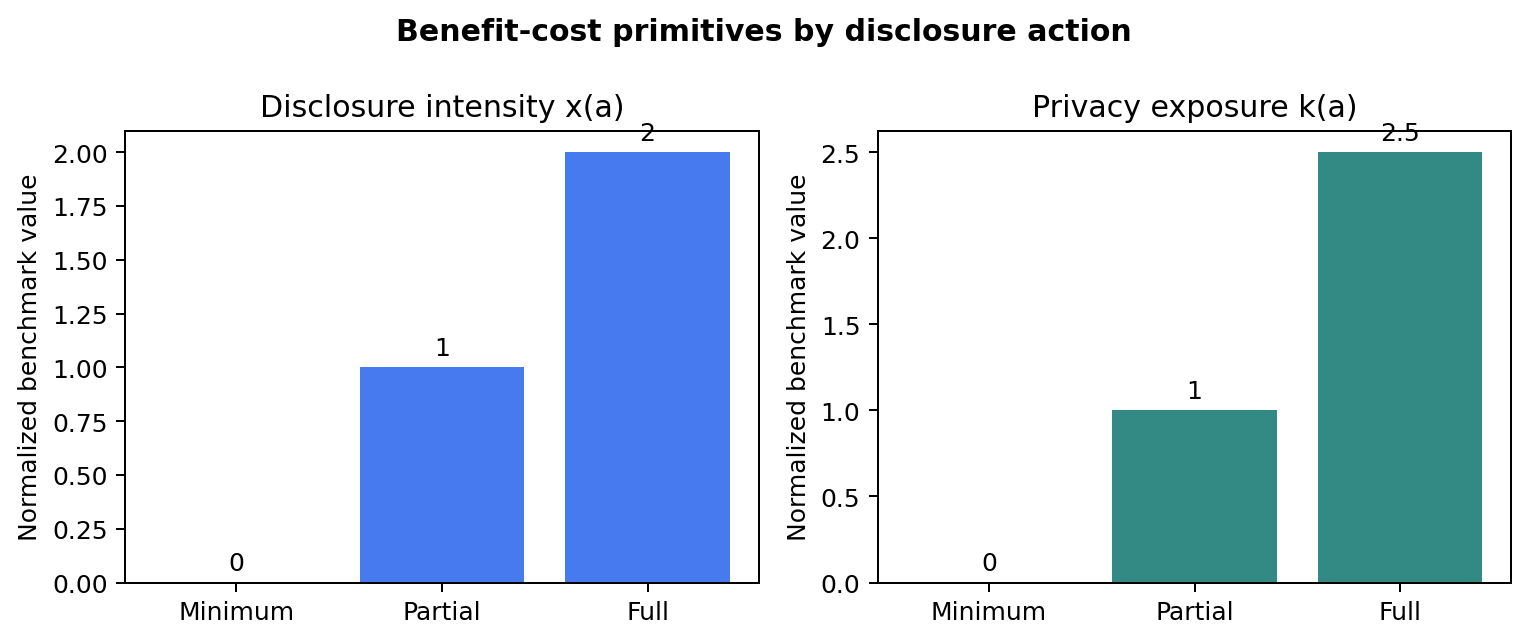

In [2]:
parameter_rows = [
    {"Symbol": "B", "Meaning": "Coordination-benefit scale", "Value": f"{BENEFIT_SCALE:g}"},
    {"Symbol": "lambda", "Meaning": "Benefit curvature", "Value": f"{LAMBDA:g}"},
    {"Symbol": "c_L", "Meaning": "Low confidentiality cost", "Value": f"{CONFIDENTIALITY_COSTS['L']:g}"},
    {"Symbol": "c_H", "Meaning": "High confidentiality cost", "Value": f"{CONFIDENTIALITY_COSTS['H']:g}"},
    {"Symbol": "q", "Meaning": "Prior probability of each type", "Value": f"{TYPE_PROB['L']:g}"},
    {"Symbol": "d", "Meaning": "Public congestion states", "Value": ", ".join(f"{value:g}" for value in CONGESTION.values())},
]
for action in ACTIONS:
    parameter_rows.append({
        "Symbol": f"x({action})",
        "Meaning": f"Disclosure intensity: {action}",
        "Value": f"{DISCLOSURE_LEVELS[action]:g}",
    })
for action in ACTIONS:
    parameter_rows.append({
        "Symbol": f"k({action})",
        "Meaning": f"Privacy exposure: {action}",
        "Value": f"{PRIVACY_COSTS[action]:g}",
    })
display_table(parameter_rows, [("Symbol", "Symbol"), ("Meaning", "Meaning"), ("Value", "Value")])

action_positions = np.arange(len(ACTIONS))
fig, axes = plt.subplots(1, 2, figsize=(8.6, 3.6), sharex=True)
for ax, values, title, color in [
    (axes[0], [DISCLOSURE_LEVELS[action] for action in ACTIONS], "Disclosure intensity x(a)", "#2563EB"),
    (axes[1], [PRIVACY_COSTS[action] for action in ACTIONS], "Privacy exposure k(a)", "#0F766E"),
]:
    bars = ax.bar(action_positions, values, color=color, alpha=0.85)
    ax.set_xticks(action_positions, ["Minimum", "Partial", "Full"])
    ax.set_title(title)
    ax.set_ylabel("Normalized benchmark value")
    ax.bar_label(bars, fmt="%.2g", padding=3)
fig.suptitle("Benefit-cost primitives by disclosure action", fontweight="bold")
fig.tight_layout()
save_figure(fig, "disclosure_action_primitives")

**Interpretation.** More detailed disclosure supplies more coordination information, but also exposes more commercially sensitive detail. The private type scales the second channel.

## Direct numerical validation and complete-information payoff matrices

In [3]:
required_utility = utility("P", "P", "L", 1.0)
assert np.isclose(required_utility, 3.7409041912141827, atol=1e-9)
print(f"utility(P,P,L,High) = {required_utility:.9f}")

payoff_rows = []
for type_pair_label, type_a, type_b in [("L/L", "L", "L"), ("L/H", "L", "H")]:
    matrix = payoff_matrix(type_a, type_b, CONGESTION["Medium"])
    print(f"Medium-congestion {type_pair_label} payoff matrix; rows=A, columns=B")
    print("       ", "  ".join(f"B={action:>12}" for action in ACTIONS))
    for action_a in ACTIONS:
        cells = [f"({matrix[(action_a, action_b)][0]:.3f},{matrix[(action_a, action_b)][1]:.3f})" for action_b in ACTIONS]
        print(f"A={action_a}:  " + "  ".join(f"{cell:>12}" for cell in cells))
        for action_b in ACTIONS:
            payoff_a, payoff_b = matrix[(action_a, action_b)]
            payoff_rows.append({
                "type_pair": type_pair_label,
                "congestion": "Medium",
                "action_A": action_a,
                "action_B": action_b,
                "payoff_A": payoff_a,
                "payoff_B": payoff_b,
            })
write_csv(TABLE_DIR / "payoff_matrices_medium.csv", payoff_rows)

utility(P,P,L,High) = 3.740904191
Medium-congestion L/L payoff matrix; rows=A, columns=B
        B=           M  B=           P  B=           F
A=M:  (0.000,0.000)  (1.771,0.771)  (2.845,0.345)
A=P:  (0.771,1.771)  (1.845,1.845)  (2.496,0.996)
A=F:  (0.345,2.845)  (0.996,2.496)  (1.391,1.391)
Medium-congestion L/H payoff matrix; rows=A, columns=B
        B=           M  B=           P  B=           F
A=M:  (0.000,0.000)  (1.771,0.171)  (2.845,-1.155)
A=P:  (0.771,1.771)  (1.845,1.245)  (2.496,-0.504)
A=F:  (0.345,2.845)  (0.996,1.896)  (1.391,-0.109)


## Bayesian strategies and the interim expected-utility check

A pure Bayesian strategy maps an operator's own type to an action: $s_i:\{L,H\}\rightarrow\{M,P,F\}$. The tuple order is always `(low-type action, high-type action)`. Thus `(P,M)` means **Low type $\rightarrow$ Partial; High type $\rightarrow$ Minimum**. It does not mean Operator A chooses P and Operator B chooses M.

In [4]:
strategies = all_pure_strategies()
assert len(strategies) == 9
print("All nine strategies:", strategies)

expected_utility_rows = []
opponent_strategy = ("P", "M")
for own_type in TYPES:
    for action in ACTIONS:
        value = expected_utility_action(
            action, own_type, opponent_strategy, CONGESTION["Medium"]
        )
        expected_utility_rows.append({
            "own_type": own_type,
            "own_action": action,
            "opponent_strategy_L_H": strategy_text(opponent_strategy),
            "expected_utility": value,
        })
        print(f"type={own_type}, action={action}: {value:.3f}")
write_csv(TABLE_DIR / "expected_utility_check.csv", expected_utility_rows)

All nine strategies: (('M', 'M'), ('M', 'P'), ('M', 'F'), ('P', 'M'), ('P', 'P'), ('P', 'F'), ('F', 'M'), ('F', 'P'), ('F', 'F'))
type=L, action=M: 0.885
type=L, action=P: 1.308
type=L, action=F: 0.670
type=H, action=M: 0.885
type=H, action=P: 0.708
type=H, action=F: -0.830


In [5]:
utility_display_rows = []
for own_type in TYPES:
    type_rows = [row for row in expected_utility_rows if row["own_type"] == own_type]
    best_value = max(row["expected_utility"] for row in type_rows)
    values = {}
    for row in type_rows:
        formatted = f"{row['expected_utility']:.3f}"
        if np.isclose(row["expected_utility"], best_value, atol=TOL):
            formatted = f"**{formatted} ✓**"
        values[row["own_action"]] = formatted
    utility_display_rows.append({
        "Type": "Low confidentiality" if own_type == "L" else "High confidentiality",
        **values,
    })
display(Markdown("### Medium-congestion expected utility against opponent strategy `(P,M)`"))
display_table(
    utility_display_rows,
    [("Type", "Own private type"), ("M", "Minimum"), ("P", "Partial"), ("F", "Full")],
)

### Medium-congestion expected utility against opponent strategy `(P,M)`

| Own private type | Minimum | Partial | Full |
|---|---|---|---|
| Low confidentiality | 0.885 | **1.308 ✓** | 0.670 |
| High confidentiality | **0.885 ✓** | 0.708 | -0.830 |

> **Interpretation —** The same public congestion state produces different best responses because confidentiality cost is private information.

## Computing the pure Bayesian Nash equilibria

```text
for each congestion state:
    enumerate type-contingent strategies
    compute expected utility over rival types
    test best responses for both players and both types
    retain mutual best responses as pure BNE
```

The search evaluates all $9\times9=81$ strategy-profile pairs and does not impose symmetry. Every tuple is reported in `(Low-type action, High-type action)` order.

In [6]:
baseline_results = {}
baseline_bne_rows = []
for congestion_label, d in CONGESTION.items():
    result = find_pure_bne(d)
    assert result.profiles_checked == 81
    baseline_results[congestion_label] = result
    for equilibrium_index, (strategy_a, strategy_b) in enumerate(result, start=1):
        baseline_bne_rows.append({
            "Congestion": congestion_label,
            "d": d,
            "Equilibrium index": equilibrium_index,
            "Operator A low-type action": strategy_a[0],
            "Operator A high-type action": strategy_a[1],
            "Operator B low-type action": strategy_b[0],
            "Operator B high-type action": strategy_b[1],
            "Number of pure BNE": len(result),
            "Candidate profiles checked": result.profiles_checked,
        })
    print(congestion_label, [equilibrium_label(eq) for eq in result])

expected_bne = {
    "Low": (("M", "M"), ("M", "M")),
    "Medium": (("P", "M"), ("P", "M")),
    "High": (("P", "P"), ("P", "P")),
}
for label, result in baseline_results.items():
    assert result.equilibria == (expected_bne[label],)

write_csv(TABLE_DIR / "baseline_bne_summary.csv", baseline_bne_rows)

Low ["A('M', 'M')|B('M', 'M')"]
Medium ["A('P', 'M')|B('P', 'M')"]
High ["A('P', 'P')|B('P', 'P')"]


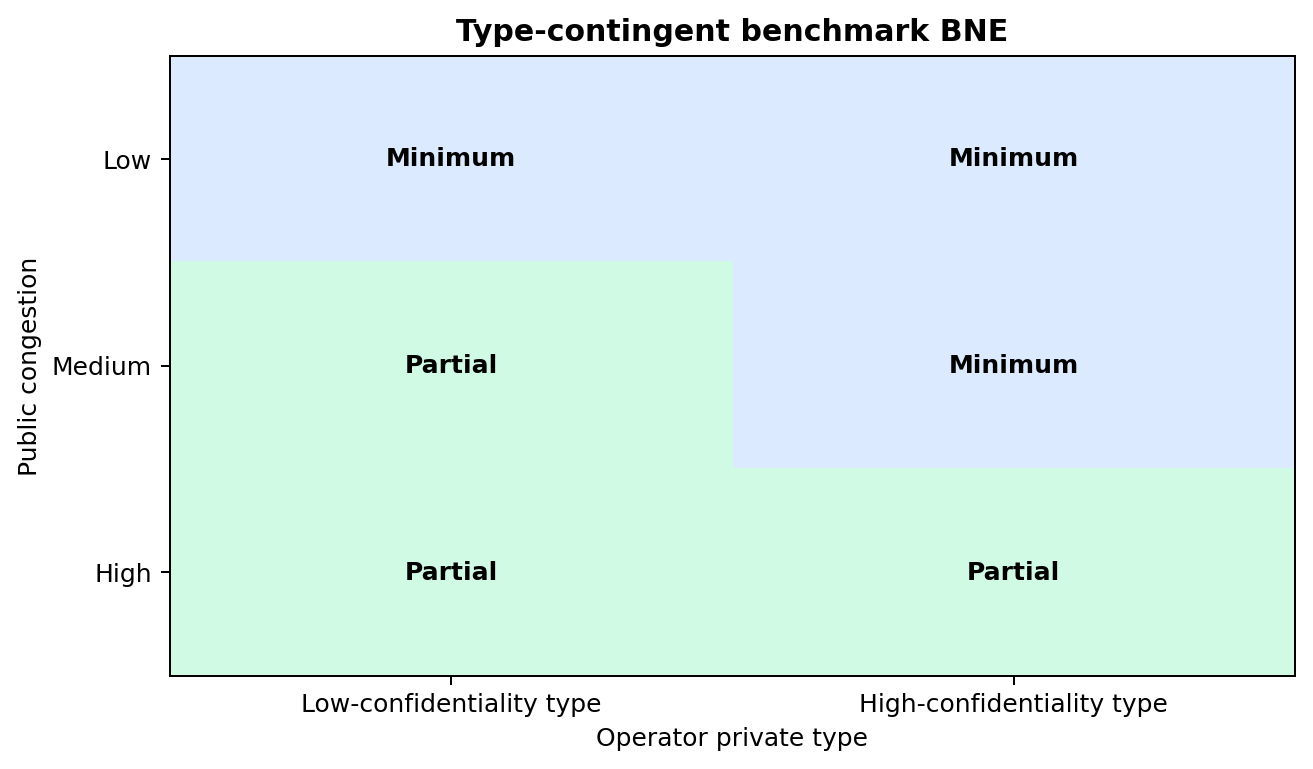

In [7]:
ACTION_LABELS = {"M": "Minimum", "P": "Partial", "F": "Full"}
ACTION_CODES = {"M": 0, "P": 1, "F": 2}
congestion_labels = list(CONGESTION)
equilibrium_matrix = []
for label in congestion_labels:
    equilibrium = baseline_results[label].equilibria[0]
    assert equilibrium[0] == equilibrium[1]
    equilibrium_matrix.append([ACTION_CODES[action] for action in equilibrium[0]])

fig, ax = plt.subplots(figsize=(7.4, 4.4))
cmap = matplotlib.colors.ListedColormap(["#DBEAFE", "#D1FAE5", "#FFEDD5"])
ax.imshow(equilibrium_matrix, cmap=cmap, vmin=-0.5, vmax=2.5, aspect="auto")
ax.set_xticks([0, 1], ["Low-confidentiality type", "High-confidentiality type"])
ax.set_yticks(range(len(congestion_labels)), congestion_labels)
ax.set_xlabel("Operator private type")
ax.set_ylabel("Public congestion")
ax.set_title("Type-contingent benchmark BNE", fontweight="bold")
for row_index, label in enumerate(congestion_labels):
    strategy = baseline_results[label].equilibria[0][0]
    for column_index, action in enumerate(strategy):
        ax.text(column_index, row_index, ACTION_LABELS[action], ha="center", va="center", fontweight="bold")
fig.tight_layout()
save_figure(fig, "baseline_bne_heatmap")

> **Interpretation —** Disclosure rises with congestion; the high-confidentiality type delays Partial disclosure at medium congestion.

## Full-information first best and expected welfare

Baseline social welfare is boundedly defined as $W=u_A+u_B$. There are no payments. For every congestion and realized type pair, a planner who observes both types enumerates all nine action profiles. This is a **full-information first best**, not automatically an implementable social optimum. All maximizing ties within numerical tolerance are retained.

In [8]:
first_best_rows = []
welfare_rows = []
for congestion_label, d in CONGESTION.items():
    for type_a in TYPES:
        for type_b in TYPES:
            result = first_best_for_types(type_a, type_b, d)
            first_best_rows.append({
                "Congestion": congestion_label,
                "d": d,
                "type_A": type_a,
                "type_B": type_b,
                "maximizing_profiles": ";".join(f"({a},{b})" for a, b in result.profiles),
                "number_of_tied_maximizers": len(result.profiles),
                "first_best_welfare": result.welfare,
            })
    equilibrium = baseline_results[congestion_label].equilibria[0]
    bne_welfare = expected_equilibrium_welfare(equilibrium, d)
    first_best_welfare = expected_first_best_welfare(d)
    welfare_rows.append({
        "Congestion": congestion_label,
        "d": d,
        "BNE welfare": bne_welfare,
        "Full-information first-best welfare": first_best_welfare,
        "Welfare gap": first_best_welfare - bne_welfare,
    })
    print(
        f"{congestion_label}: BNE={bne_welfare:.3f}, "
        f"first best={first_best_welfare:.3f}, gap={first_best_welfare-bne_welfare:.3f}"
    )

write_csv(TABLE_DIR / "first_best_by_type.csv", first_best_rows)
write_csv(TABLE_DIR / "baseline_welfare_gap.csv", welfare_rows)

Low: BNE=0.000, first best=0.639, gap=0.639
Medium: BNE=2.193, first best=3.139, gap=0.946
High: BNE=6.882, first best=7.385, gap=0.503


In [9]:
display(Markdown("### Welfare accounting by congestion"))
welfare_display_rows = [
    {
        "Congestion": row["Congestion"],
        "BNE": f"{row['BNE welfare']:.6f}",
        "First best": f"{row['Full-information first-best welfare']:.6f}",
        "Gap": f"{row['Welfare gap']:.6f}",
    }
    for row in welfare_rows
]
display_table(
    welfare_display_rows,
    [("Congestion", "Congestion"), ("BNE", "BNE welfare"), ("First best", "Full-information first best"), ("Gap", "Gap")],
)
largest_gap_row = max(welfare_rows, key=lambda row: row["Welfare gap"])
display(Markdown(
    f"> **Main annotation — Largest benchmark gap: {largest_gap_row['Congestion']} congestion "
    f"({largest_gap_row['Welfare gap']:.3f}).**"
))

### Welfare accounting by congestion

| Congestion | BNE welfare | Full-information first best | Gap |
|---|---|---|---|
| Low | 0.000000 | 0.639095 | 0.639095 |
| Medium | 2.192883 | 3.139085 | 0.946202 |
| High | 6.881808 | 7.385238 | 0.503429 |

> **Main annotation — Largest benchmark gap: Medium congestion (0.946).**

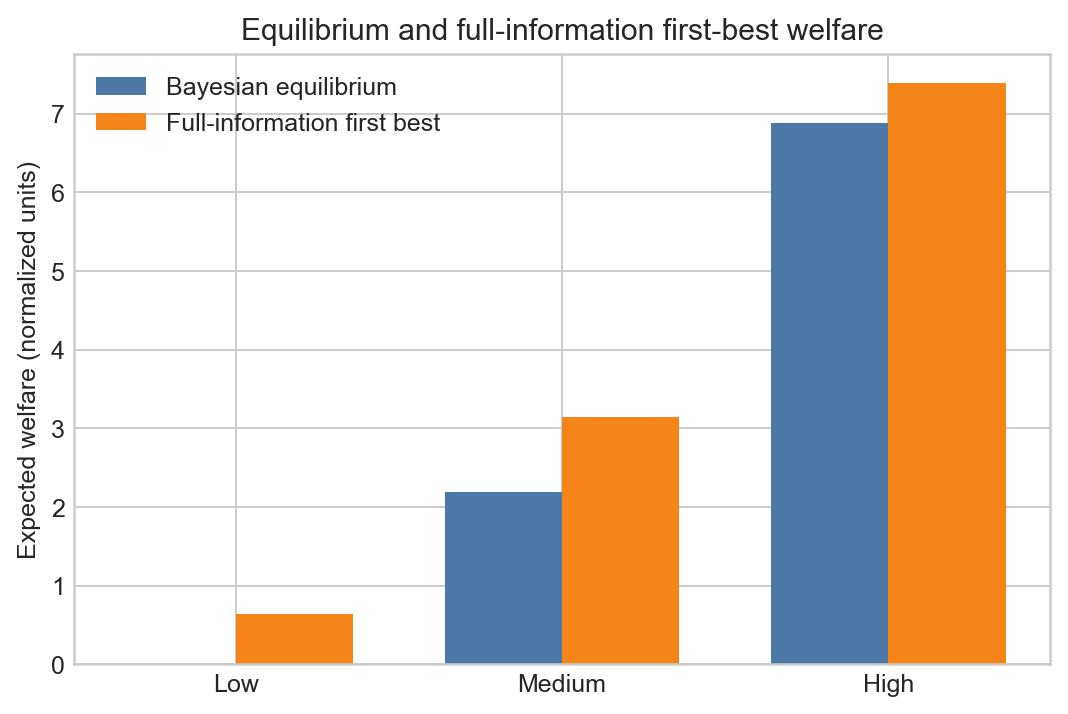

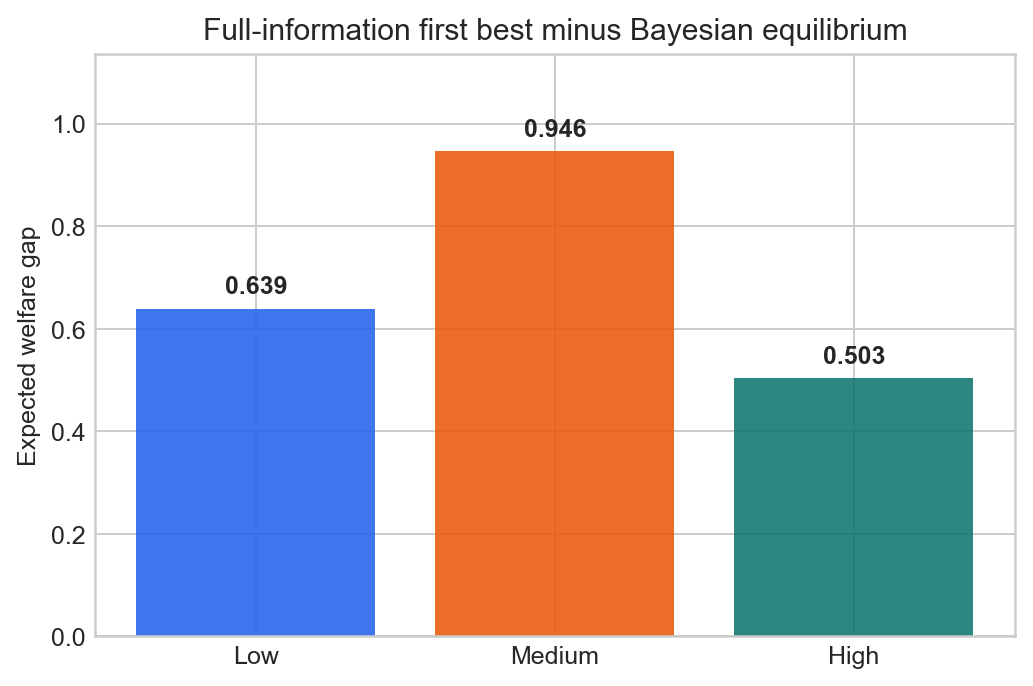

In [10]:
plt.style.use("seaborn-v0_8-whitegrid")
labels = [row["Congestion"] for row in welfare_rows]
x_positions = np.arange(len(labels))
bne_values = [row["BNE welfare"] for row in welfare_rows]
fb_values = [row["Full-information first-best welfare"] for row in welfare_rows]
gaps = [row["Welfare gap"] for row in welfare_rows]

fig, ax = plt.subplots(figsize=(7.0, 4.4))
width = 0.36
ax.bar(x_positions - width/2, bne_values, width, label="Bayesian equilibrium", color="#4C78A8")
ax.bar(x_positions + width/2, fb_values, width, label="Full-information first best", color="#F58518")
ax.set_xticks(x_positions, labels)
ax.set_ylabel("Expected welfare (normalized units)")
ax.set_title("Equilibrium and full-information first-best welfare")
ax.legend(frameon=False)
save_figure(fig, "baseline_welfare_comparison")

fig, ax = plt.subplots(figsize=(6.6, 4.2))
gap_bars = ax.bar(labels, gaps, color=["#2563EB", "#EA580C", "#0F766E"], alpha=0.88)
ax.set_ylim(0, max(gaps) * 1.20)
ax.set_ylabel("Expected welfare gap")
ax.set_title("Full-information first best minus Bayesian equilibrium")
ax.bar_label(gap_bars, labels=[f"{value:.3f}" for value in gaps], padding=4, fontweight="bold")
save_figure(fig, "baseline_welfare_gap")

In [11]:
def first_best_row(congestion, type_a, type_b):
    return next(
        row for row in first_best_rows
        if row["Congestion"] == congestion and row["type_A"] == type_a and row["type_B"] == type_b
    )

low_hh = first_best_row("Low", "H", "H")
high_ll = first_best_row("High", "L", "L")
display(Markdown(
    "### Efficiency and disclosure burden\n\n"
    f"- **Low congestion, H/H:** tied first-best profiles: `{low_hh['maximizing_profiles']}`.\n"
    f"- **High congestion, L/L:** tied first-best profiles: `{high_ll['maximizing_profiles']}`.\n\n"
    "> **Interpretation —** Efficient disclosure need not be symmetric. Efficiency and the distribution of disclosure burden can diverge; this is an observation from the benchmark, not a formal fairness theorem."
))

### Efficiency and disclosure burden

- **Low congestion, H/H:** tied first-best profiles: `(M,P);(P,M)`.
- **High congestion, L/L:** tied first-best profiles: `(P,F);(F,P)`.

> **Interpretation —** Efficient disclosure need not be symmetric. Efficiency and the distribution of disclosure burden can diverge; this is an observation from the benchmark, not a formal fairness theorem.

## Candidate mechanism: Congestion-Contingent Access Rule (CCAR)

| Public congestion | $\alpha(M)$ | $\alpha(P)$ | $\alpha(F)$ |
|---|---:|---:|---:|
| Low | 1 | 1 | 1 |
| Medium / High | $\alpha_M$ | 1 | 1 |

The benchmark uses $\alpha_M=0.7$. CCAR affects access to enhanced non-safety coordination information after Minimum voluntary disclosure; **mandatory safety information remains universal and unchanged**.

Operator behavior is evaluated using restricted CCAR utility. Welfare comparisons retain the baseline underlying value of disclosure, so the access restriction itself is not counted as a social benefit. CCAR is a candidate mechanism, not a claim of optimality or universal success.

In [12]:
ccar_bne_rows = []
ccar_benchmark = {}
for congestion_label, d in CONGESTION.items():
    result = find_pure_bne(d, ccar=True, alpha_m=ALPHA_M)
    ccar_benchmark[congestion_label] = result
    for equilibrium_index, equilibrium in enumerate(result, start=1):
        strategy_a, strategy_b = equilibrium
        ccar_bne_rows.append({
            "Congestion": congestion_label,
            "d": d,
            "alpha_M": ALPHA_M,
            "Equilibrium index": equilibrium_index,
            "A strategy (L,H)": strategy_text(strategy_a),
            "B strategy (L,H)": strategy_text(strategy_b),
            "Number of pure BNE": len(result),
            "Underlying expected welfare": expected_equilibrium_welfare(
                equilibrium, d, ccar=True, alpha_m=ALPHA_M
            ),
            "CCAR operator-utility sum": expected_equilibrium_welfare(
                equilibrium, d, accounting="operator", ccar=True, alpha_m=ALPHA_M
            ),
            "Full-information first-best welfare": expected_first_best_welfare(d),
        })
    print(congestion_label, [equilibrium_label(eq) for eq in result])

expected_ccar = {
    "Low": (("M", "M"), ("M", "M")),
    "Medium": (("P", "P"), ("P", "P")),
    "High": (("P", "P"), ("P", "P")),
}
for label, result in ccar_benchmark.items():
    assert result.equilibria == (expected_ccar[label],)
write_csv(TABLE_DIR / "ccar_bne_summary.csv", ccar_bne_rows)

Low ["A('M', 'M')|B('M', 'M')"]
Medium ["A('P', 'P')|B('P', 'P')"]
High ["A('P', 'P')|B('P', 'P')"]


| Case | Low type | High type | Welfare | Gap |
|---|---|---|---|---|
| Baseline | Partial | Minimum | 2.192883 | 0.946202 |
| CCAR (alpha_M=0.7) | Partial | Partial | 3.089085 | 0.050000 |

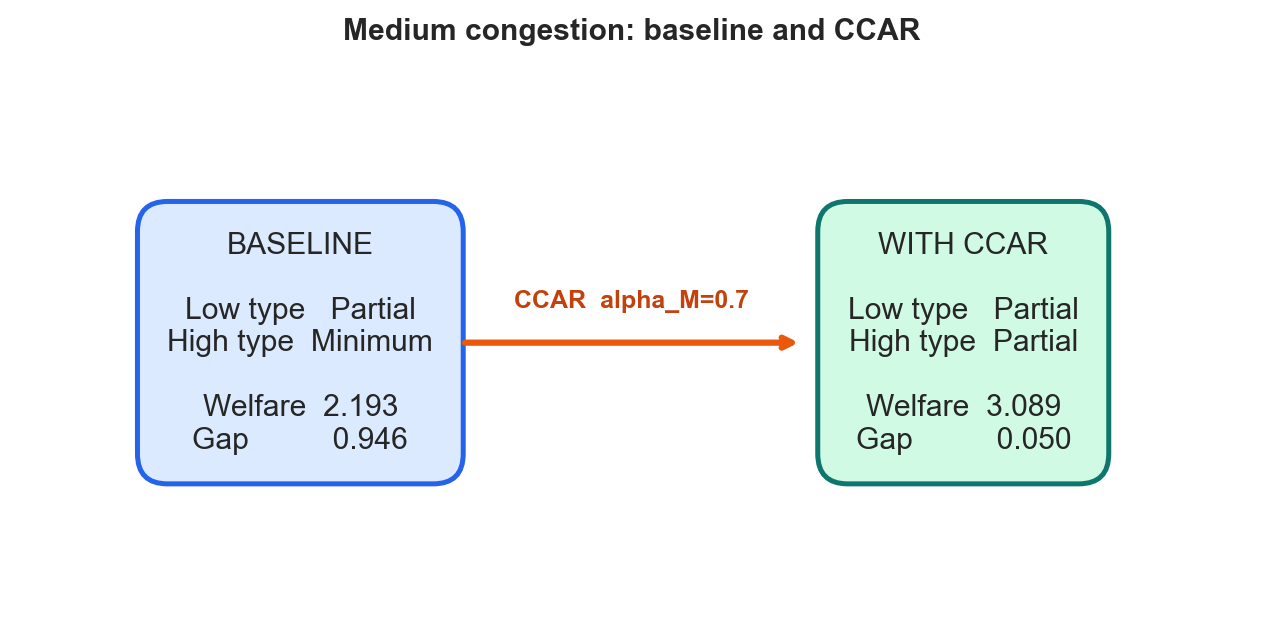

In [13]:
baseline_medium = baseline_results["Medium"].equilibria[0][0]
ccar_medium = ccar_benchmark["Medium"].equilibria[0][0]
baseline_medium_welfare = next(row["BNE welfare"] for row in welfare_rows if row["Congestion"] == "Medium")
medium_first_best = next(row["Full-information first-best welfare"] for row in welfare_rows if row["Congestion"] == "Medium")
ccar_medium_row = next(row for row in ccar_bne_rows if row["Congestion"] == "Medium")
ccar_medium_welfare = ccar_medium_row["Underlying expected welfare"]

display_table(
    [
        {
            "Case": "Baseline",
            "Low type": ACTION_LABELS[baseline_medium[0]],
            "High type": ACTION_LABELS[baseline_medium[1]],
            "Welfare": f"{baseline_medium_welfare:.6f}",
            "Gap": f"{medium_first_best - baseline_medium_welfare:.6f}",
        },
        {
            "Case": f"CCAR (alpha_M={ALPHA_M:g})",
            "Low type": ACTION_LABELS[ccar_medium[0]],
            "High type": ACTION_LABELS[ccar_medium[1]],
            "Welfare": f"{ccar_medium_welfare:.6f}",
            "Gap": f"{medium_first_best - ccar_medium_welfare:.6f}",
        },
    ],
    [("Case", "Case"), ("Low type", "Low type"), ("High type", "High type"), ("Welfare", "Welfare"), ("Gap", "Gap")],
)

fig, ax = plt.subplots(figsize=(8.8, 3.8))
ax.axis("off")
left = (
    "BASELINE\n\n"
    f"Low type   {ACTION_LABELS[baseline_medium[0]]}\n"
    f"High type  {ACTION_LABELS[baseline_medium[1]]}\n\n"
    f"Welfare  {baseline_medium_welfare:.3f}\n"
    f"Gap          {medium_first_best - baseline_medium_welfare:.3f}"
)
right = (
    "WITH CCAR\n\n"
    f"Low type   {ACTION_LABELS[ccar_medium[0]]}\n"
    f"High type  {ACTION_LABELS[ccar_medium[1]]}\n\n"
    f"Welfare  {ccar_medium_welfare:.3f}\n"
    f"Gap          {medium_first_best - ccar_medium_welfare:.3f}"
)
ax.text(0.23, 0.5, left, ha="center", va="center", fontsize=12, bbox=dict(boxstyle="round,pad=1", fc="#DBEAFE", ec="#2563EB", lw=2))
ax.text(0.77, 0.5, right, ha="center", va="center", fontsize=12, bbox=dict(boxstyle="round,pad=1", fc="#D1FAE5", ec="#0F766E", lw=2))
ax.annotate("", xy=(0.64, 0.5), xytext=(0.36, 0.5), arrowprops=dict(arrowstyle="->", lw=2.5, color="#EA580C"))
ax.text(0.50, 0.58, f"CCAR  alpha_M={ALPHA_M:g}", ha="center", va="center", color="#C2410C", fontweight="bold")
ax.set_title("Medium congestion: baseline and CCAR", fontweight="bold", pad=16)
save_figure(fig, "ccar_medium_before_after")

> **Interpretation —** At the benchmark, CCAR changes the high-confidentiality type from Minimum to Partial and sharply narrows the medium-congestion welfare gap. Mechanism performance remains parameter-dependent.

## CCAR $\alpha_M$ sensitivity: grid thresholds are approximate, not analytical

In [14]:
alpha_values = np.round(np.arange(0.50, 1.0001, 0.05), 2)
alpha_rows = []
for congestion_label in ("Medium", "High"):
    d = CONGESTION[congestion_label]
    previous_set = None
    for alpha_m in alpha_values:
        result = find_pure_bne(d, ccar=True, alpha_m=float(alpha_m))
        equilibrium_set = tuple(equilibrium_label(eq) for eq in result)
        switched = previous_set is not None and equilibrium_set != previous_set
        if result.equilibria:
            for equilibrium_index, equilibrium in enumerate(result, start=1):
                strategy_a, strategy_b = equilibrium
                welfare = expected_equilibrium_welfare(
                    equilibrium, d, ccar=True, alpha_m=float(alpha_m)
                )
                alpha_rows.append({
                    "Congestion": congestion_label,
                    "d": d,
                    "alpha_M": alpha_m,
                    "Equilibrium index": equilibrium_index,
                    "A strategy (L,H)": strategy_text(strategy_a),
                    "B strategy (L,H)": strategy_text(strategy_b),
                    "Underlying expected welfare": welfare,
                    "CCAR operator-utility sum": expected_equilibrium_welfare(
                        equilibrium,
                        d,
                        accounting="operator",
                        ccar=True,
                        alpha_m=float(alpha_m),
                    ),
                    "Full-information first-best welfare": expected_first_best_welfare(d),
                    "Welfare gap": expected_first_best_welfare(d) - welfare,
                    "Number of pure BNE": len(result),
                    "Equilibrium set switched from prior grid point": switched,
                })
        else:
            alpha_rows.append({
                "Congestion": congestion_label,
                "d": d,
                "alpha_M": alpha_m,
                "Equilibrium index": "",
                "A strategy (L,H)": "",
                "B strategy (L,H)": "",
                "Underlying expected welfare": "",
                "CCAR operator-utility sum": "",
                "Full-information first-best welfare": expected_first_best_welfare(d),
                "Welfare gap": "",
                "Number of pure BNE": 0,
                "Equilibrium set switched from prior grid point": switched,
            })
        if switched:
            print(
                f"{congestion_label}: equilibrium set changes between the previous grid point "
                f"and alpha_M={alpha_m:.2f}; this is only a grid threshold."
            )
        previous_set = equilibrium_set
write_csv(TABLE_DIR / "ccar_alpha_sensitivity.csv", alpha_rows)

Medium: equilibrium set changes between the previous grid point and alpha_M=0.75; this is only a grid threshold.
Medium: equilibrium set changes between the previous grid point and alpha_M=0.80; this is only a grid threshold.


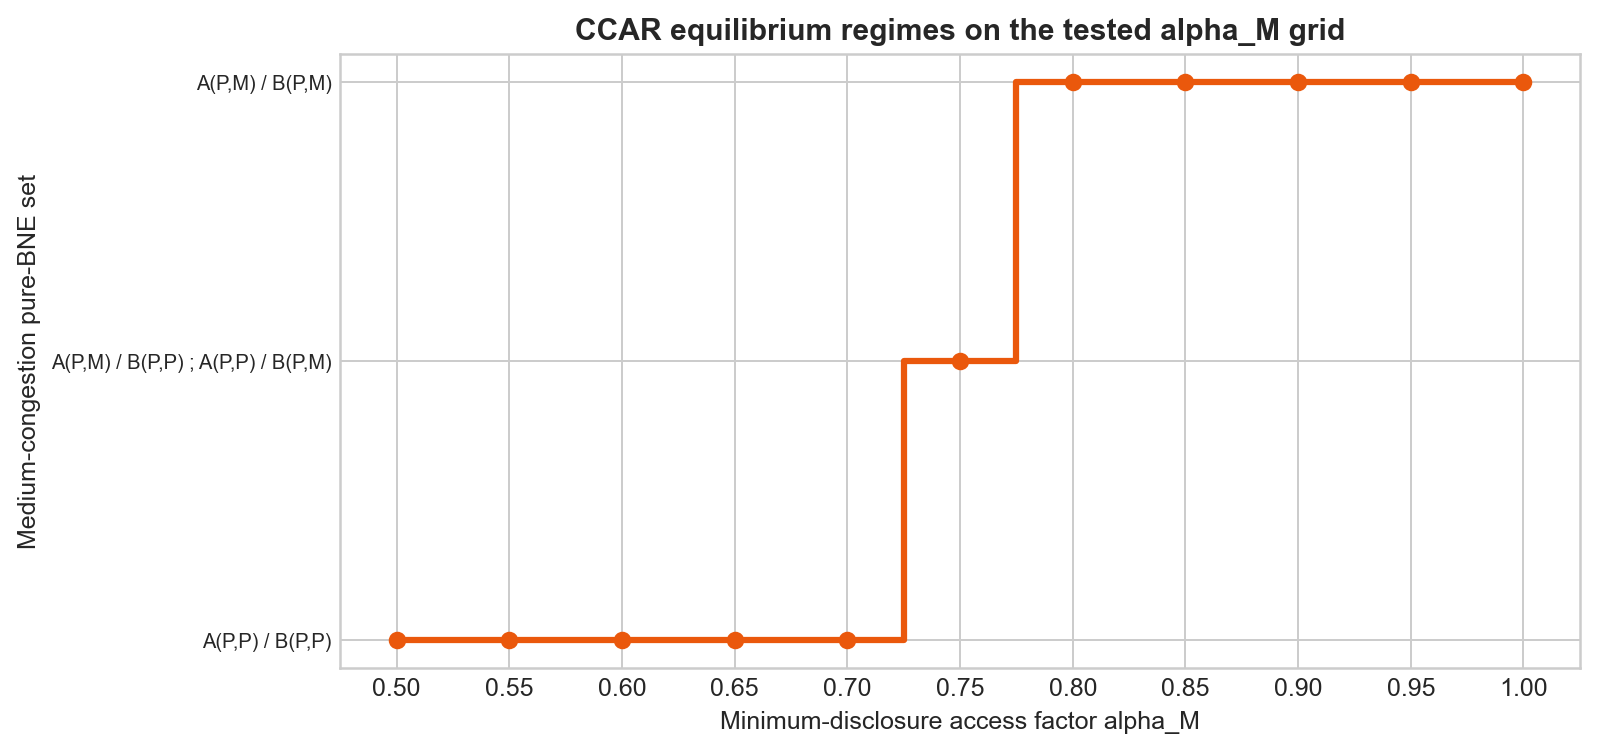

> **Grid interpretation —** The displayed changes are numerical diagnostics on the tested grid, not analytical threshold proofs.

In [15]:
medium_regimes = {}
for alpha_m in alpha_values:
    matches = [
        row for row in alpha_rows
        if row["Congestion"] == "Medium" and np.isclose(row["alpha_M"], alpha_m)
    ]
    profiles = [f"A{row['A strategy (L,H)']} / B{row['B strategy (L,H)']}" for row in matches]
    medium_regimes[float(alpha_m)] = " ; ".join(profiles) or "No pure BNE"

regime_order = list(dict.fromkeys(medium_regimes.values()))
regime_codes = {label: index for index, label in enumerate(regime_order)}
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.step(
    list(medium_regimes),
    [regime_codes[label] for label in medium_regimes.values()],
    where="mid",
    color="#EA580C",
    linewidth=2.5,
    marker="o",
)
ax.set_xticks(alpha_values)
ax.set_yticks(range(len(regime_order)), regime_order, fontsize=8)
ax.set_xlabel("Minimum-disclosure access factor alpha_M")
ax.set_ylabel("Medium-congestion pure-BNE set")
ax.set_title("CCAR equilibrium regimes on the tested alpha_M grid", fontweight="bold")
fig.tight_layout()
save_figure(fig, "ccar_alpha_regime_transitions")
display(Markdown(
    "> **Grid interpretation —** The displayed changes are numerical diagnostics on the tested grid, not analytical threshold proofs."
))

## Confidentiality sensitivity and equilibrium phase diagram

In [16]:
c_high_values = np.round(np.arange(1.1, 3.0001, 0.1), 1)
confidentiality_rows = []
phase_sets = {}
for mechanism in ("Baseline", "CCAR"):
    for congestion_label, d in CONGESTION.items():
        for c_high in c_high_values:
            confidentiality_costs = {"L": 1.0, "H": float(c_high)}
            kwargs = {"confidentiality_costs": confidentiality_costs}
            if mechanism == "CCAR":
                kwargs.update({"ccar": True, "alpha_m": ALPHA_M})
            result = find_pure_bne(d, **kwargs)
            phase_sets[(mechanism, congestion_label, c_high)] = "; ".join(
                equilibrium_label(eq) for eq in result
            ) or "No pure BNE"
            if result.equilibria:
                for equilibrium_index, equilibrium in enumerate(result, start=1):
                    welfare = expected_equilibrium_welfare(equilibrium, d, **kwargs)
                    confidentiality_rows.append({
                        "Mechanism": mechanism,
                        "Congestion": congestion_label,
                        "d": d,
                        "c_L": 1.0,
                        "c_H": c_high,
                        "alpha_M": ALPHA_M if mechanism == "CCAR" else 1.0,
                        "Equilibrium index": equilibrium_index,
                        "A strategy (L,H)": strategy_text(equilibrium[0]),
                        "B strategy (L,H)": strategy_text(equilibrium[1]),
                        "Underlying expected welfare": welfare,
                        "Full-information first-best welfare": expected_first_best_welfare(
                            d, confidentiality_costs=confidentiality_costs
                        ),
                        "Number of pure BNE": len(result),
                    })
            else:
                confidentiality_rows.append({
                    "Mechanism": mechanism,
                    "Congestion": congestion_label,
                    "d": d,
                    "c_L": 1.0,
                    "c_H": c_high,
                    "alpha_M": ALPHA_M if mechanism == "CCAR" else 1.0,
                    "Equilibrium index": "",
                    "A strategy (L,H)": "",
                    "B strategy (L,H)": "",
                    "Underlying expected welfare": "",
                    "Full-information first-best welfare": expected_first_best_welfare(
                        d, confidentiality_costs=confidentiality_costs
                    ),
                    "Number of pure BNE": 0,
                })
write_csv(TABLE_DIR / "confidentiality_sensitivity.csv", confidentiality_rows)

all_phase_labels = sorted(set(phase_sets.values()))
phase_code = {label: index for index, label in enumerate(all_phase_labels)}
fig, axes = plt.subplots(2, 1, figsize=(10.5, 7.5), sharex=True)
colors = {"Low": "#4C78A8", "Medium": "#F58518", "High": "#54A24B"}
for ax, mechanism in zip(axes, ("Baseline", "CCAR"), strict=True):
    for congestion_label in CONGESTION:
        y_values = [phase_code[phase_sets[(mechanism, congestion_label, value)]] for value in c_high_values]
        ax.step(c_high_values, y_values, where="mid", label=congestion_label, color=colors[congestion_label])
    ax.set_title(mechanism)
    ax.set_yticks(range(len(all_phase_labels)), all_phase_labels, fontsize=7)
    ax.set_ylabel("Pure-BNE set")
    ax.legend(frameon=False, ncol=3)
axes[-1].set_xlabel("High-type confidentiality sensitivity $c_H$ ($c_L=1$)")
fig.suptitle("Equilibrium phase diagram under confidentiality sensitivity", y=1.01)
fig.tight_layout()
save_figure(fig, "confidentiality_equilibrium_phase", show=False)

In [17]:
def compress_regimes(mechanism, congestion):
    entries = [(float(value), phase_sets[(mechanism, congestion, value)]) for value in c_high_values]
    groups = []
    start_value, prior_value, prior_label = entries[0][0], entries[0][0], entries[0][1]
    for value, label in entries[1:]:
        if label != prior_label:
            groups.append((start_value, prior_value, prior_label))
            start_value, prior_label = value, label
        prior_value = value
    groups.append((start_value, prior_value, prior_label))
    return groups

confidentiality_summary = []
for mechanism in ("Baseline", "CCAR"):
    for congestion in CONGESTION:
        for lower, upper, regime in compress_regimes(mechanism, congestion):
            interval = f"{lower:.1f}" if np.isclose(lower, upper) else f"{lower:.1f}–{upper:.1f}"
            confidentiality_summary.append({
                "Mechanism": mechanism,
                "Congestion": congestion,
                "c_H grid range": interval,
                "Pure-BNE set": regime,
            })
display(Markdown("### Meaningful confidentiality-cost regime changes"))
display_table(
    confidentiality_summary,
    [("Mechanism", "Mechanism"), ("Congestion", "Congestion"), ("c_H grid range", "c_H grid range"), ("Pure-BNE set", "Pure-BNE set")],
)

### Meaningful confidentiality-cost regime changes

| Mechanism | Congestion | c_H grid range | Pure-BNE set |
|---|---|---|---|
| Baseline | Low | 1.1–3.0 | A('M', 'M')|B('M', 'M') |
| Baseline | Medium | 1.1–1.4 | A('P', 'M')|B('P', 'P'); A('P', 'P')|B('P', 'M') |
| Baseline | Medium | 1.5–3.0 | A('P', 'M')|B('P', 'M') |
| Baseline | High | 1.1–1.7 | A('P', 'P')|B('P', 'P') |
| Baseline | High | 1.8–2.3 | A('P', 'M')|B('P', 'P'); A('P', 'P')|B('P', 'M') |
| Baseline | High | 2.4–3.0 | A('P', 'M')|B('P', 'M') |
| CCAR | Low | 1.1–3.0 | A('M', 'M')|B('M', 'M') |
| CCAR | Medium | 1.1–1.6 | A('P', 'P')|B('P', 'P') |
| CCAR | Medium | 1.7–3.0 | A('P', 'M')|B('P', 'M') |
| CCAR | High | 1.1–2.6 | A('P', 'P')|B('P', 'P') |
| CCAR | High | 2.7–2.8 | A('P', 'M')|B('P', 'P'); A('P', 'P')|B('P', 'M') |
| CCAR | High | 2.9–3.0 | A('P', 'M')|B('P', 'M') |

## Full-disclosure cost robustness

In [18]:
k_full_values = np.round(np.arange(1.2, 3.5001, 0.1), 1)
full_rows = []
for mechanism in ("Baseline", "CCAR"):
    for congestion_label, d in CONGESTION.items():
        for k_full in k_full_values:
            privacy_costs = dict(PRIVACY_COSTS)
            privacy_costs["F"] = float(k_full)
            kwargs = {"privacy_costs": privacy_costs}
            if mechanism == "CCAR":
                kwargs.update({"ccar": True, "alpha_m": ALPHA_M})
            result = find_pure_bne(d, **kwargs)
            full_best_response = False
            for opponent_strategy in all_pure_strategies():
                for own_type in TYPES:
                    action_values = {
                        action: expected_utility_action(
                            action, own_type, opponent_strategy, d, **kwargs
                        )
                        for action in ACTIONS
                    }
                    if action_values["F"] >= max(action_values.values()) - TOL:
                        full_best_response = True
            if result.equilibria:
                for equilibrium_index, equilibrium in enumerate(result, start=1):
                    full_rows.append({
                        "Mechanism": mechanism,
                        "Congestion": congestion_label,
                        "d": d,
                        "k_F": k_full,
                        "Equilibrium index": equilibrium_index,
                        "A strategy (L,H)": strategy_text(equilibrium[0]),
                        "B strategy (L,H)": strategy_text(equilibrium[1]),
                        "Full appears in equilibrium": any(
                            action == "F" for strategy in equilibrium for action in strategy
                        ),
                        "Full is a best response somewhere": full_best_response,
                        "Underlying expected welfare": expected_equilibrium_welfare(
                            equilibrium, d, **kwargs
                        ),
                        "Number of pure BNE": len(result),
                    })
            else:
                full_rows.append({
                    "Mechanism": mechanism,
                    "Congestion": congestion_label,
                    "d": d,
                    "k_F": k_full,
                    "Equilibrium index": "",
                    "A strategy (L,H)": "",
                    "B strategy (L,H)": "",
                    "Full appears in equilibrium": False,
                    "Full is a best response somewhere": full_best_response,
                    "Underlying expected welfare": "",
                    "Number of pure BNE": 0,
                })
write_csv(TABLE_DIR / "full_disclosure_sensitivity.csv", full_rows)

for mechanism in ("Baseline", "CCAR"):
    for congestion_label in CONGESTION:
        relevant = [
            row for row in full_rows
            if row["Mechanism"] == mechanism
            and row["Congestion"] == congestion_label
            and row["Full appears in equilibrium"]
        ]
        if relevant:
            print(
                mechanism,
                congestion_label,
                "Full appears in equilibrium on the tested grid for k_F up to",
                max(row["k_F"] for row in relevant),
            )

Baseline Low Full appears in equilibrium on the tested grid for k_F up to 1.4
Baseline Medium Full appears in equilibrium on the tested grid for k_F up to 2.0
Baseline High Full appears in equilibrium on the tested grid for k_F up to 2.4
CCAR Low Full appears in equilibrium on the tested grid for k_F up to 1.4
CCAR Medium Full appears in equilibrium on the tested grid for k_F up to 1.8
CCAR High Full appears in equilibrium on the tested grid for k_F up to 2.0


| Mechanism | Congestion | Largest tested k(F) with Full in a BNE |
|---|---|---|
| Baseline | Low | 1.4 |
| Baseline | Medium | 2.0 |
| Baseline | High | 2.4 |
| CCAR | Low | 1.4 |
| CCAR | Medium | 1.8 |
| CCAR | High | 2.0 |

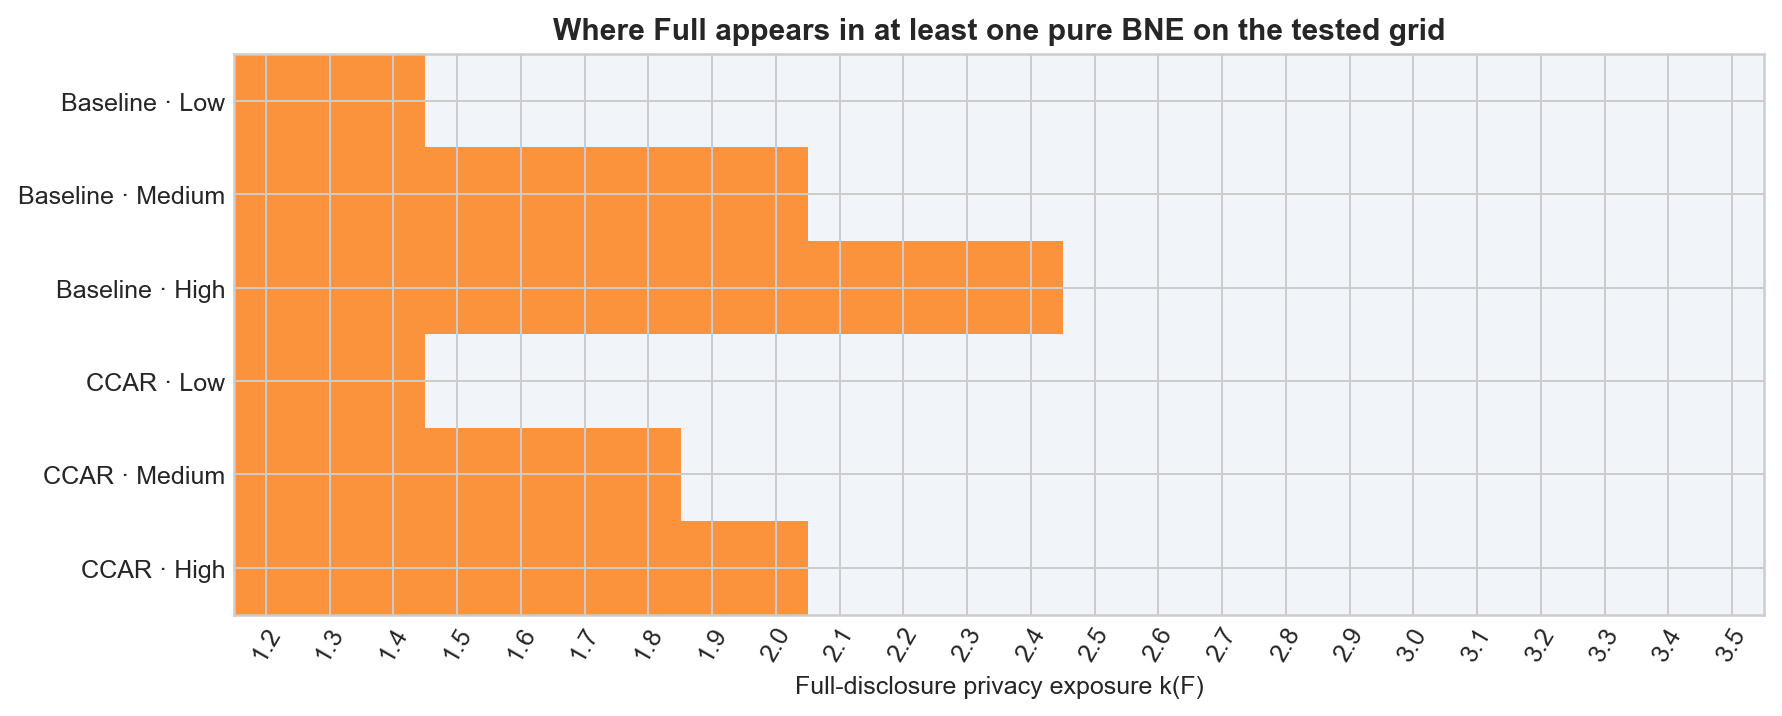

> **Why Full is absent from the benchmark BNE —** At benchmark `k(F)=2.5`, its added coordination benefit does not offset its type-scaled privacy exposure in equilibrium. The sweep shows that Full can emerge when `k(F)` is reduced; this is a comparative-static diagnostic, not empirical calibration.

In [19]:
full_presence_rows = []
heatmap_rows = []
heatmap_labels = []
for mechanism in ("Baseline", "CCAR"):
    for congestion in CONGESTION:
        presence = []
        for k_full in k_full_values:
            present = any(
                row["Mechanism"] == mechanism
                and row["Congestion"] == congestion
                and np.isclose(row["k_F"], k_full)
                and row["Full appears in equilibrium"]
                for row in full_rows
            )
            presence.append(int(present))
        supported = [value for value, present in zip(k_full_values, presence) if present]
        full_presence_rows.append({
            "Mechanism": mechanism,
            "Congestion": congestion,
            "Largest tested k(F) with Full in a BNE": f"{max(supported):.1f}" if supported else "None on grid",
        })
        heatmap_rows.append(presence)
        heatmap_labels.append(f"{mechanism} · {congestion}")

display_table(
    full_presence_rows,
    [("Mechanism", "Mechanism"), ("Congestion", "Congestion"), ("Largest tested k(F) with Full in a BNE", "Largest tested k(F) with Full in a BNE")],
)
fig, ax = plt.subplots(figsize=(10.0, 4.1))
ax.imshow(heatmap_rows, aspect="auto", cmap=matplotlib.colors.ListedColormap(["#F1F5F9", "#FB923C"]), vmin=0, vmax=1)
ax.set_yticks(range(len(heatmap_labels)), heatmap_labels)
ax.set_xticks(range(len(k_full_values)), [f"{value:.1f}" for value in k_full_values], rotation=60)
ax.set_xlabel("Full-disclosure privacy exposure k(F)")
ax.set_title("Where Full appears in at least one pure BNE on the tested grid", fontweight="bold")
fig.tight_layout()
save_figure(fig, "full_disclosure_equilibrium_sensitivity")

benchmark_full = PRIVACY_COSTS["F"]
display(Markdown(
    f"> **Why Full is absent from the benchmark BNE —** At benchmark `k(F)={benchmark_full:g}`, "
    "its added coordination benefit does not offset its type-scaled privacy exposure in equilibrium. "
    "The sweep shows that Full can emerge when `k(F)` is reduced; this is a comparative-static diagnostic, not empirical calibration."
))

## Mechanism failure-region search

This diagnostic searches a broader grid: $\alpha_M\in\{0.10,0.15,\ldots,1.00\}$, $c_H\in\{1.1,1.2,\ldots,3.0\}$, at Medium and High congestion with benchmark $k(F)$. “Robust welfare improvement” means the worst CCAR pure-BNE welfare exceeds the best baseline pure-BNE welfare. “Excessive disclosure” means at least one CCAR equilibrium has expected disclosure above the mean disclosure across tied full-information first-best profiles. “Increased gap” flags any CCAR equilibrium whose gap exceeds the worst baseline-equilibrium gap. These are transparent grid diagnostics, not analytical global results.

In [20]:
failure_rows = []
failure_alpha_values = np.round(np.arange(0.10, 1.0001, 0.05), 2)
for congestion_label in ("Medium", "High"):
    d = CONGESTION[congestion_label]
    for c_high in c_high_values:
        confidentiality_costs = {"L": 1.0, "H": float(c_high)}
        baseline = find_pure_bne(d, confidentiality_costs=confidentiality_costs)
        baseline_welfare = [
            expected_equilibrium_welfare(
                equilibrium, d, confidentiality_costs=confidentiality_costs
            )
            for equilibrium in baseline
        ]
        baseline_disclosure = [expected_equilibrium_disclosure(eq) for eq in baseline]
        first_best_welfare = expected_first_best_welfare(
            d, confidentiality_costs=confidentiality_costs
        )
        first_best_disclosure = expected_first_best_disclosure(
            d, confidentiality_costs=confidentiality_costs
        )
        for alpha_m in failure_alpha_values:
            ccar = find_pure_bne(
                d,
                confidentiality_costs=confidentiality_costs,
                ccar=True,
                alpha_m=float(alpha_m),
            )
            ccar_welfare = [
                expected_equilibrium_welfare(
                    equilibrium,
                    d,
                    confidentiality_costs=confidentiality_costs,
                    ccar=True,
                    alpha_m=float(alpha_m),
                )
                for equilibrium in ccar
            ]
            ccar_disclosure = [expected_equilibrium_disclosure(eq) for eq in ccar]
            no_effect = set(baseline.equilibria) == set(ccar.equilibria)
            robust_improvement = bool(
                baseline_welfare
                and ccar_welfare
                and min(ccar_welfare) > max(baseline_welfare) + TOL
            )
            excessive = bool(
                ccar_disclosure
                and max(ccar_disclosure) > first_best_disclosure + TOL
            )
            increased_gap = bool(
                baseline_welfare
                and ccar_welfare
                and max(first_best_welfare - value for value in ccar_welfare)
                > max(first_best_welfare - value for value in baseline_welfare) + TOL
            )
            failure_rows.append({
                "Congestion": congestion_label,
                "d": d,
                "c_H": c_high,
                "alpha_M": alpha_m,
                "Baseline pure BNE": ";".join(equilibrium_label(eq) for eq in baseline),
                "CCAR pure BNE": ";".join(equilibrium_label(eq) for eq in ccar),
                "Baseline BNE count": len(baseline),
                "CCAR BNE count": len(ccar),
                "No effect on equilibrium set": no_effect,
                "Robust welfare improvement": robust_improvement,
                "Excessive disclosure by stated diagnostic": excessive,
                "Any CCAR gap exceeds worst baseline gap": increased_gap,
                "Multiple CCAR pure BNE": len(ccar) > 1,
                "No CCAR pure BNE": len(ccar) == 0,
                "Baseline welfare min": min(baseline_welfare) if baseline_welfare else "",
                "Baseline welfare max": max(baseline_welfare) if baseline_welfare else "",
                "CCAR welfare min": min(ccar_welfare) if ccar_welfare else "",
                "CCAR welfare max": max(ccar_welfare) if ccar_welfare else "",
                "Full-information first-best welfare": first_best_welfare,
            })
write_csv(TABLE_DIR / "ccar_failure_regions.csv", failure_rows)

diagnostics = [
    "No effect on equilibrium set",
    "Robust welfare improvement",
    "Excessive disclosure by stated diagnostic",
    "Any CCAR gap exceeds worst baseline gap",
    "Multiple CCAR pure BNE",
    "No CCAR pure BNE",
]
for diagnostic in diagnostics:
    print(diagnostic, sum(bool(row[diagnostic]) for row in failure_rows), "of", len(failure_rows))

No effect on equilibrium set 401 of 760
Robust welfare improvement 334 of 760
Excessive disclosure by stated diagnostic 18 of 760
Any CCAR gap exceeds worst baseline gap 3 of 760
Multiple CCAR pure BNE 66 of 760
No CCAR pure BNE 0 of 760


In [21]:
diagnostic_labels = {
    "No effect on equilibrium set": "No equilibrium-set effect",
    "Robust welfare improvement": "Welfare improvement",
    "Excessive disclosure by stated diagnostic": "Excessive-disclosure diagnostic",
    "Any CCAR gap exceeds worst baseline gap": "Larger welfare gap",
    "Multiple CCAR pure BNE": "Multiple pure CCAR BNE",
    "No CCAR pure BNE": "No pure CCAR BNE",
}
failure_summary = [
    {"Diagnostic": label, "Count": sum(bool(row[key]) for row in failure_rows)}
    for key, label in diagnostic_labels.items()
]
display(Markdown(f"### CCAR robustness search: {len(failure_rows)} tested parameter cells"))
display_table(failure_summary, [("Diagnostic", "Diagnostic"), ("Count", "Count")])
display(Markdown(
    "> **Reading the table —** Categories overlap; these counts are not probabilities. The grid is a diagnostic search, not a proof over a continuous parameter space."
))

### CCAR robustness search: 760 tested parameter cells

| Diagnostic | Count |
|---|---|
| No equilibrium-set effect | 401 |
| Welfare improvement | 334 |
| Excessive-disclosure diagnostic | 18 |
| Larger welfare gap | 3 |
| Multiple pure CCAR BNE | 66 |
| No pure CCAR BNE | 0 |

> **Reading the table —** Categories overlap; these counts are not probabilities. The grid is a diagnostic search, not a proof over a continuous parameter space.

## Interpretation and evidence boundary

The benchmark links public congestion to type-contingent voluntary disclosure and identifies where private incentives depart from a planner who observes realized types. CCAR can change those incentives, but its effect varies with access and confidentiality parameters.

> **Evidence boundary —** These are computational findings for a small stylized game. They do not estimate operator behavior, operational risk, legal compliance, enforcement cost, or real airspace capacity.

Extensions include correlated or interdependent types, continuous disclosure, repeated interaction and reputation, heterogeneous congestion exposure, compliance and auditing costs, endogenous congestion, mixed equilibria, and a fuller implementability analysis.

In [22]:
package_names = ["numpy", "matplotlib", "nbformat", "nbclient", "ipykernel"]
metadata_rows = [
    {"item": "python_version", "value": platform.python_version()},
    *[{"item": f"package_{name}", "value": metadata.version(name)} for name in package_names],
    {"item": "actions", "value": str(ACTIONS)},
    {"item": "types", "value": str(TYPES)},
    {"item": "type_probabilities", "value": str(TYPE_PROB)},
    {"item": "congestion", "value": str(CONGESTION)},
    {"item": "benefit_scale_B", "value": BENEFIT_SCALE},
    {"item": "lambda", "value": LAMBDA},
    {"item": "benchmark_alpha_M", "value": ALPHA_M},
    {"item": "table_output_path", "value": str(TABLE_DIR.relative_to(ROOT))},
    {"item": "figure_output_path", "value": str(FIGURE_DIR.relative_to(ROOT))},
]
write_csv(TABLE_DIR / "disclosure_run_metadata.csv", metadata_rows)
print("Reproducibility record")
for row in metadata_rows:
    print(f"{row['item']}: {row['value']}")

Reproducibility record
python_version: 3.13.7
package_numpy: 2.3.5
package_matplotlib: 3.10.8
package_nbformat: 5.10.4
package_nbclient: 0.10.2
package_ipykernel: 7.1.0
actions: ('M', 'P', 'F')
types: ('L', 'H')
type_probabilities: {'L': 0.5, 'H': 0.5}
congestion: {'Low': 0.3, 'Medium': 0.6, 'High': 1.0}
benefit_scale_B: 7.5
lambda: 0.5
benchmark_alpha_M: 0.7
table_output_path: outputs/tables
figure_output_path: outputs/figures


In [23]:
summary_rows = []
for label in CONGESTION:
    strategy = baseline_results[label].equilibria[0][0]
    summary_rows.append({
        "Congestion": label,
        "Low type": ACTION_LABELS[strategy[0]],
        "High type": ACTION_LABELS[strategy[1]],
    })
display(Markdown("## Main benchmark result"))
display_table(summary_rows, [("Congestion", "Congestion"), ("Low type", "Low type"), ("High type", "High type")])
display(Markdown(
    f"**Largest welfare gap:** {largest_gap_row['Congestion']} `{largest_gap_row['Welfare gap']:.3f}`  \n"
    f"**CCAR benchmark at Medium:** `{ACTION_LABELS[ccar_medium[0]]}/{ACTION_LABELS[ccar_medium[1]]}`  \n"
    f"**Remaining gap:** `{medium_first_best - ccar_medium_welfare:.3f}`  \n\n"
    "**Evidence boundary:** stylized computational benchmark."
))

## Main benchmark result

| Congestion | Low type | High type |
|---|---|---|
| Low | Minimum | Minimum |
| Medium | Partial | Minimum |
| High | Partial | Partial |

**Largest welfare gap:** Medium `0.946`  
**CCAR benchmark at Medium:** `Partial/Partial`  
**Remaining gap:** `0.050`  

**Evidence boundary:** stylized computational benchmark.

### Continue exploring

- [GitHub repository](https://github.com/dku-comsci-econ206-Autumn2026/PS2-FP10-ShareOrHide-Yiqiao)
- [Run this notebook in Colab](https://colab.research.google.com/github/dku-comsci-econ206-Autumn2026/PS2-FP10-ShareOrHide-Yiqiao/blob/main/notebooks/01_strategic_disclosure_game.ipynb)
- [Behavioral Decision Lab](https://huggingface.co/spaces/dku-comsci-econ206-2026/ps2-share-or-hide-drone-disclosure)